In [1]:

# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("/kaggle/input/datasets/luckysingh7518/tweets/Tweets (1).csv")
df.columns = df.columns.str.strip()

# 🔥 limit data for speed
df = df.sample(1000, random_state=42)

TEXT_COL = "text"
LABEL_COL = "sentiment"

df = df[[TEXT_COL, LABEL_COL]].dropna()

texts = df[TEXT_COL].astype(str).tolist()

label_map = {"negative": 0, "neutral": 1, "positive": 2}
labels = [label_map[x] for x in df[LABEL_COL]]


In [3]:

# ================================
# 3. TRAIN-VALIDATION SPLIT
# ================================
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)


In [4]:
# ================================
# 4. TOKENIZATION
# ================================
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(
    train_texts,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt"
)

val_encodings = tokenizer(
    val_texts,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt"
)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [5]:
# ================================
# 5. DATASET CLASS
# ================================
class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TweetDataset(train_encodings, train_labels)
val_dataset = TweetDataset(val_encodings, val_labels)


In [6]:
# ================================
# 6. DATALOADERS
# ================================
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)


In [7]:

# ================================
# 7. MODEL
# ================================
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,
    output_attentions=True
)

# 🔥 freeze BERT for speed
for param in model.bert.parameters():
    param.requires_grad = False

optimizer = AdamW(model.parameters(), lr=2e-5)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [8]:
# ================================
# 8. TRAINING + VALIDATION
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

EPOCHS = 5

for epoch in range(EPOCHS):
    # ===== TRAIN =====
    model.train()
    train_loss, correct, total = 0, 0, 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == batch['labels']).sum().item()
        total += batch['labels'].size(0)

    train_acc = correct / total

    # ===== VALIDATION =====
    model.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=1)

            val_correct += (preds == batch['labels']).sum().item()
            val_total += batch['labels'].size(0)

    val_acc = val_correct / val_total

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print("-" * 40)


Epoch 1: 100%|██████████| 200/200 [00:04<00:00, 48.43it/s]



Epoch 1
Train Loss: 1.1387
Train Accuracy: 0.3050
Validation Accuracy: 0.3550
----------------------------------------


Epoch 2: 100%|██████████| 200/200 [00:02<00:00, 69.70it/s]



Epoch 2
Train Loss: 1.0837
Train Accuracy: 0.4062
Validation Accuracy: 0.3900
----------------------------------------


Epoch 3: 100%|██████████| 200/200 [00:02<00:00, 67.99it/s]



Epoch 3
Train Loss: 1.0883
Train Accuracy: 0.4075
Validation Accuracy: 0.4000
----------------------------------------


Epoch 4: 100%|██████████| 200/200 [00:02<00:00, 69.37it/s]



Epoch 4
Train Loss: 1.0764
Train Accuracy: 0.4188
Validation Accuracy: 0.4000
----------------------------------------


Epoch 5: 100%|██████████| 200/200 [00:02<00:00, 68.70it/s]



Epoch 5
Train Loss: 1.0771
Train Accuracy: 0.4175
Validation Accuracy: 0.4000
----------------------------------------


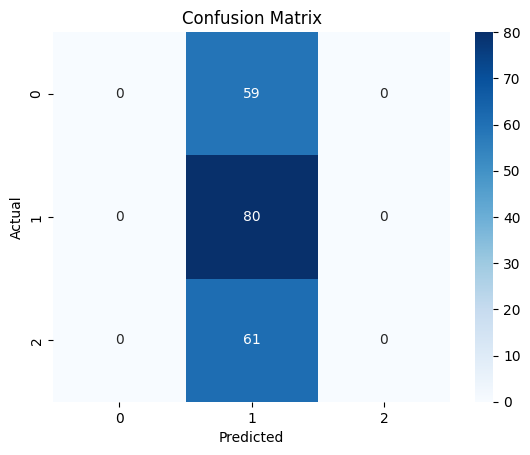

In [9]:
# ================================
# 9. CONFUSION MATRIX
# ================================
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)

        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [10]:
# ================================
# 10. PREDICTION
# ================================
label_names = {0: "negative", 1: "neutral", 2: "positive"}

def predict(text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1).item()

    print("Text:", text)
    print("Predicted Sentiment:", label_names[pred])


In [11]:

# ================================
# 11. ATTENTION VISUALIZATION
# ================================
def visualize_attention(text):
    model.eval()

    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions
    attention = attentions[-1][0][0].cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    plt.figure(figsize=(10,8))
    sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.title("Attention Heatmap")
    plt.show()


Text: The movie was okay, not too good not too bad
Predicted Sentiment: neutral


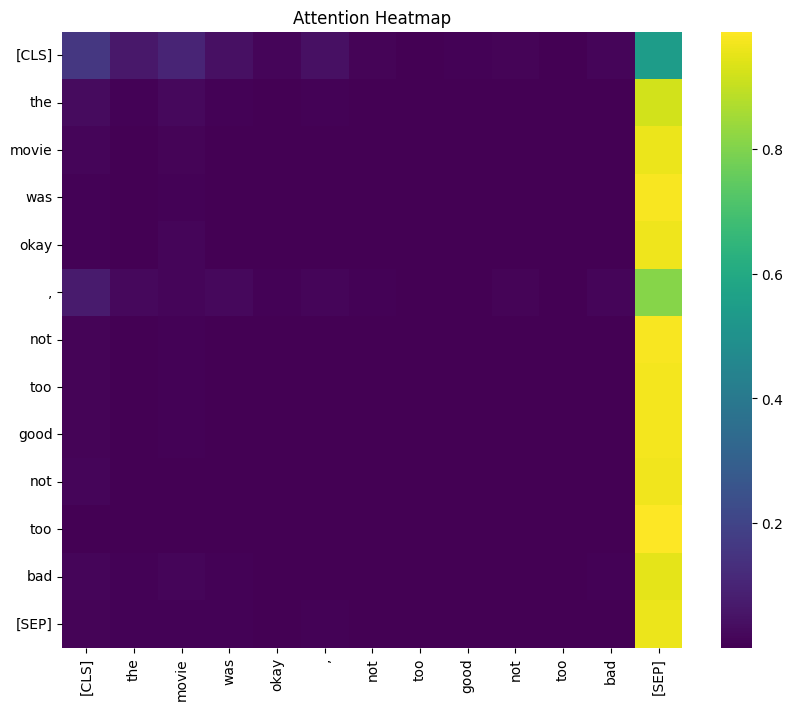

In [12]:
# ================================
# 12. TEST
# ================================
test_tweet = "The movie was okay, not too good not too bad"

predict(test_tweet)
visualize_attention(test_tweet)